In [26]:
import pandas as pd
from dateutil.relativedelta import relativedelta
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Nivell 1
Importa com un DataFrame l'arxiu encuesta_trabajadores.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

- Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
- Mostra les primeres 10 files.


In [4]:
df = pd.read_excel("Encuesta_trabajadores.xlsx", header = 3, index_col = 0)     # Importar el df con columnas correctas
df = df.sort_values(by=["País d'origen", "Ciutat"])
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


- Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [5]:
df["DNI"].is_unique

True

2. Crea una columna que sigui el nom complet.


In [ ]:
df["nombre_completo"] = df["Nom"] + " " + df["Cognoms"]

Crea una columna si la persona és nascuda a Espanya o no.

In [7]:
df["Nacida_en_España"] = df["País d'origen"] == "Espanya"

Posa el DNI com a índex del DataFrame (noms de files).

In [8]:
df = df.set_index("DNI")

Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.

In [9]:
df = df.rename(columns={"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Año"})

Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

In [10]:
df["Gènere"] = df["Gènere"].replace({"H": "Home", "D": "Dona", "A": "Altres", "NC": None})

Mostra tots els canvis que has realitzat en una sola taula.

In [17]:
df[["nombre_completo", "Nacida_en_España", "Dia", "Mes", "Año", "Gènere"]].head()

,nombre_completo,Nacida_en_España,Dia,Mes,Año,Gènere
DNI,,,,,,
28973553Z,Mia Schneider Fischer,False,22,10,1976,Altres
37399141L,Laura Schneider Fischer,False,2,2,1958,Dona
37368317L,Lea Schneider Schneider,False,23,10,2005,Dona
21390098Z,Mia Fischer,False,11,8,1950,Dona
44060014R,Jonas Schneider,False,22,11,1985,Home


3.
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [18]:
# Comprobar que no hay filas con los dos valores NaN
print(df[df["Fills"].isna() & df["No Fills"].isna()])

# Comprobar que no hay filas con los dos valores 1.0
print(df[(df["Fills"] == 1.0) & (df["No Fills"] == 1.0)])

def hijos(Fills):
    return "Sí" if Fills == 1.0 else "No"

Empty DataFrame
Columns: [Nom, Cognoms, País d'origen, Ciutat, Dia, Mes, Año, Gènere, Salari mensual, Fills, No Fills, Grup Professional, nombre_completo, Nacida_en_España]
Index: []
Empty DataFrame
Columns: [Nom, Cognoms, País d'origen, Ciutat, Dia, Mes, Año, Gènere, Salari mensual, Fills, No Fills, Grup Professional, nombre_completo, Nacida_en_España]
Index: []


In [19]:
df["Hijos"] = df["Fills"].apply(hijos)
df

# Solución con lambda
# df["Hijos"] = df["Fills"].apply(lambda x: "Sí" if x == 1.0 else "No")

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,nombre_completo,Nacida_en_España,Hijos
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False,Sí
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,False,Sí
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,False,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,False,Sí
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,False,No


4.
Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.

Ordena la taula en funció del sou mig.

Convertir columna salario en números tratables (quitarle €, punto y posibles espacios)

In [ ]:
df["Salari mensual"] = df["Salari mensual"].str.replace("€", "").str.replace(".", "").str.strip().astype(float)

In [154]:
tabla_resumen_genero = df.groupby("Gènere")["Salari mensual"].agg(
    Promedio = "mean",
    Mediana = "median",
    Mínimo = "min",
    Máximo = "max"
).round(2).sort_values("Promedio")

tabla_resumen_genero

,Promedio,Mediana,Mínimo,Máximo
Gènere,,,,
Dona,1469.44,1361.5,665.0,3021.0
Altres,1626.59,1545.0,703.0,3175.0
Home,1643.25,1531.0,737.0,3356.0


5.
Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).

Afegeix-hi les mitjanes als marges de la taula.

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [ ]:
salario_genero_pais = pd.pivot_table(
    df,
    values = "Salari mensual",
    index = "Gènere",
    columns = "País d'origen",
    aggfunc = "mean",
    margins = True,           # añade totales en las márgenes
    margins_name = "Media"    # nombre de las márgenes
).round(2)

# EXTRA formato condicional
salario_genero_pais.style.background_gradient(cmap="Purples").format("{:.2f}")



País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Media
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Media,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


6.
Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. 

In [23]:
df['fecha_nacimiento'] = pd.to_datetime(dict(year=df['Año'], month=df['Mes'], day=df['Dia']))

Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.

In [24]:
def calcular_edad(fecha_nacimiento):
    return relativedelta(date.today(), fecha_nacimiento).years

Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [25]:
df['edad_actual'] = df['fecha_nacimiento'].apply(calcular_edad)
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,nombre_completo,Nacida_en_España,Hijos,fecha_nacimiento,edad_actual
DNI,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False,Sí,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False,No,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,False,Sí,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False,Sí,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,False,No,1958-03-28,68
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,False,Sí,1979-12-27,46
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,False,No,1952-08-28,73


## Nivell 2
1.
Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":

["5%","3,5%","2%","8%"]})

 Dataframe increment

In [ ]:
df_increment = pd.DataFrame({
    "Grup Professional": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Increment": ["5%", "3,5%", "2%", "8%"]
})

Unir al Dataframe principal

In [ ]:
df = df.merge(df_increment, on = "Grup Professional", how = "left")

Convertir los porcentajes a números tratables en Python

In [ ]:
df["Increment"] = df["Increment"].str.replace("%", "").str.replace(",", ".").astype(float) / 100

df["Salari mensual"] = (df["Salari mensual"] + (df["Salari mensual"] * df["Increment"])).round(2)
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,nombre_completo,Nacida_en_España,Hijos,fecha_nacimiento,edad_actual,Increment
0,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,NaN,1.0,Grup A,Mia Schneider Fischer,False,No,1976-10-22,49,0.050
1,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.92,1.0,NaN,Grup B,Laura Schneider Fischer,False,Sí,1958-02-02,68,0.035
2,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.46,NaN,1.0,Grup B,Lea Schneider Schneider,False,No,2005-10-23,20,0.035
3,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.50,1.0,NaN,Grup B,Mia Fischer,False,Sí,1950-08-11,75,0.035
4,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,1.0,NaN,Grup D,Jonas Schneider,False,Sí,1985-11-22,40,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.16,NaN,1.0,Grup B,Emily Taylor Jones,False,No,1958-03-28,68,0.035
996,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.50,1.0,NaN,Grup A,George Brown Jones,False,Sí,1979-12-27,46,0.050
997,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.15,NaN,1.0,Grup A,Olivia Brown Brown,False,No,1952-08-28,73,0.050
998,Isla,Jones Brown,Regne Unit,Manchester,28,3,1999,Dona,1256.85,NaN,1.0,Grup A,Isla Jones Brown,False,No,1999-03-28,27,0.050


Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

In [159]:
for grupo in df["Grup Professional"].unique():  # .unique() para garantizar que sea un solo grupo
    df_grupo = df[df["Grup Professional"] == grupo]
    nombre = grupo.replace(" ", "_")
    df_grupo.to_csv(f"datos_{nombre}.csv", index=False)

Para verificar que se hayan exportado los grupos profesionales

In [ ]:
print(os.listdir())

['matriu_distancies.xlsx', 'Encuesta_trabajadores.xlsx', 'encuestas.ipynb', 'datos_Grup_D.csv', 'datos_Grup_C.csv', 'datos_Grup_B.csv', 'datos_Grup_A.csv']


Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [ ]:
resumen_grupos = df.groupby("Grup Professional").agg(
    trabajadores = ("Nom", "count"),
    salario_promedio = ("Salari mensual", "mean"),
    edad_promedio = ("edad_actual", "median")
).round(2)

resumen_grupos.to_csv("resum_grups.csv", index=True)
resumen_grupos

,trabajadores,salario_promedio,edad_promedio
Grup Professional,,,
Grup A,490,1213.32,51.0
Grup B,318,1724.55,48.0
Grup C,137,2289.19,52.0
Grup D,55,3100.82,44.0


## Nivell 3
El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

1.
Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

- un histograma/boxplot si la variable és numèrica
- unes barres dels valors més freqüents si és categòrica
- unes barres dels anys més freqüents si la dada està en format data.
- La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

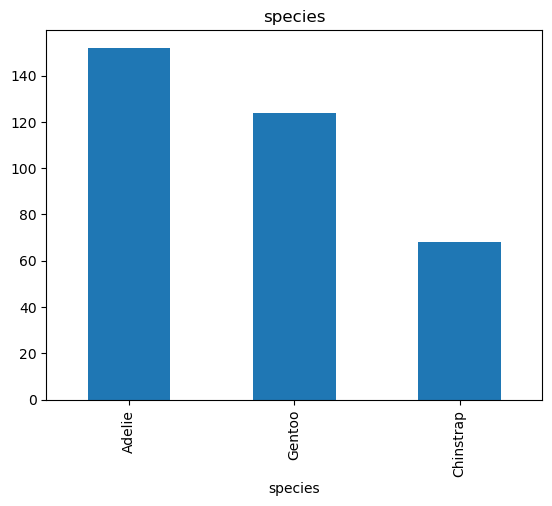

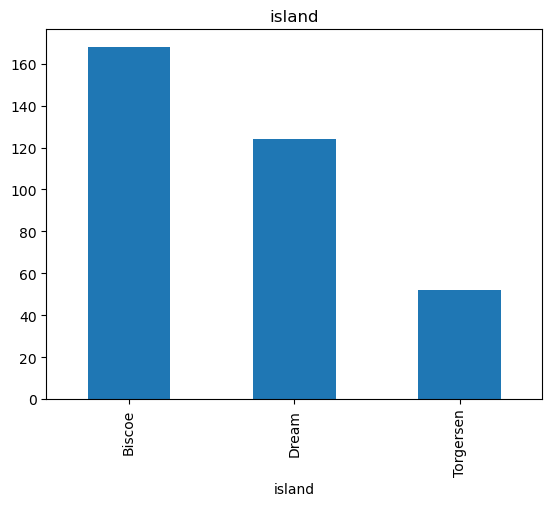

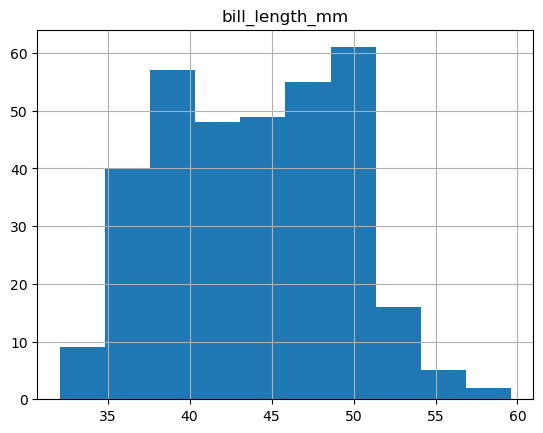

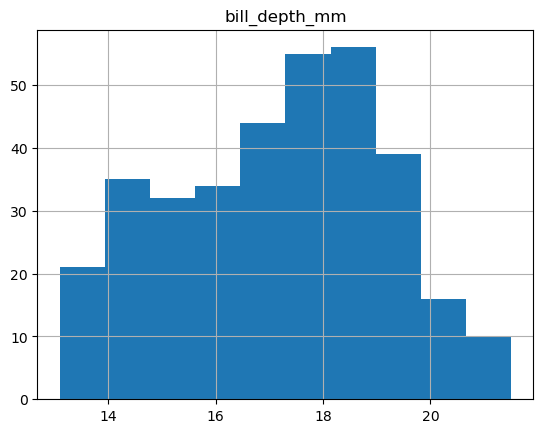

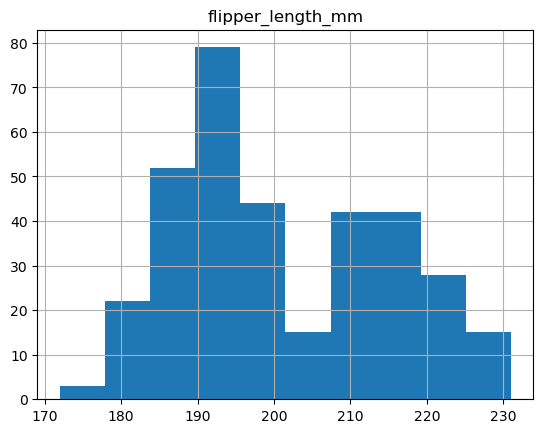

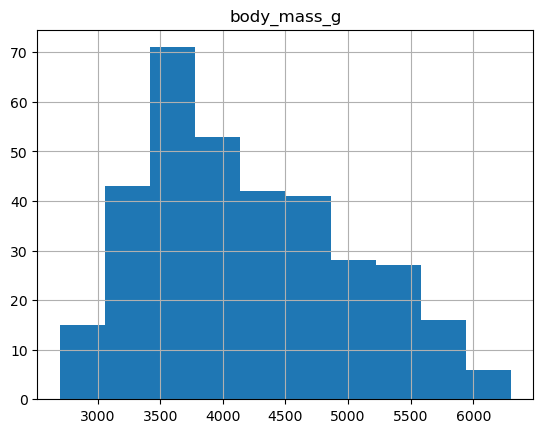

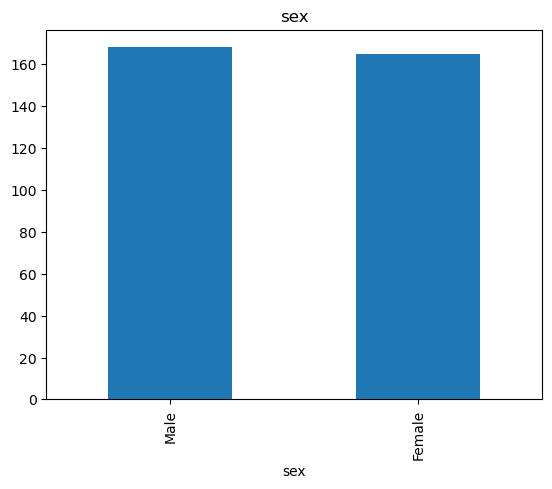

In [ ]:
def grafics_automatics(df):
    for columna in df.columns:
        fig, ax = plt.subplots()
        
        if pd.api.types.is_numeric_dtype(df[columna]):
            df[columna].hist(ax=ax)
        elif pd.api.types.is_datetime64_any_dtype(df[columna]):
            df[columna].dt.year.value_counts().sort_index().plot(kind="bar", ax=ax)
        else:
            df[columna].value_counts().head(10).plot(kind="bar", ax=ax)
        
        ax.set_title(columna)
        plt.savefig(f"graf_{columna}.png")
        plt.show()

df_penguins = sns.load_dataset("penguins")
grafics_automatics(df_penguins)